## Summary

The purpose of this notebook is to illustrate the main experiments from the paper Financial Anomaly Detection of the Canadian Market by Luigi Caputi and Nicholas Meadows.

The project compares three approaches (PCA, Topological Data Analysis, and Graph Neural Networks) for detecting early warning signals of financial stress in the Canadian economy.

This notebook is not intended to run the full pipeline. Instead, it provides interactive visualizations of the key results, allowing the user to explore the correlation structure, graph features and anomaly scores across different methods.

In [68]:
import itertools
from re import L
from turtle import mode
import numpy as np
import networkx as nx
import statistics
import pandas as pd
import math
import yfinance as yf
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import datetime as dt
import matplotlib.dates as mdates
from ipywidgets import widgets

## Data Loading

This notebook does not run the full pipeline from the paper, which includes preprocessing, correlation construction, TDA feature extraction, PCA reduction, and GNN training.

Instead, we load the precomputed anomaly scores and evaluation metrics for each method and use this notebook to visualize and compare the results.

This cell will load files containing the required results.

In [69]:
from google.colab import drive
drive.mount('/content/gdrive')
anomalies = np.load('data/results/Anomalies.npy')
results = pd.read_csv("data/results/results-final(CAD).csv")

# we use TD stock for the reference of the business calendar in Canada
ref_stock = yf.download("TD.TO", start="2005-01-01", end="2022-01-01")

# Ticker symbols for the correlation matrix
ticker_symbols = [
    'BCE', 'WN', 'BMO', 'IFC', 'GIL', 'SU', 'MG', 'CAE', 'POW', 'IMO',
    'CCO', 'FTS', 'FM', 'K', 'L', 'SLF', 'AEM', 'CM', 'TRP', 'ABX',
    'CNQ', 'ENB', 'WPM', 'EMA', 'SAP', 'AQN', 'BNS', 'NA', 'CNR', 'RY',
    'MFC', 'T', 'ATD', 'MRU', 'CP', 'WCN', 'OTEX', 'TD', 'BN'
]

# the dates of seven extreme events in the Canadian economy between 2005-2021
extreme_event_dates_CFSI = [('2007', '9'), ('2009', '1'), ('2011', '10'), ('2013', '4'), ('2015', '1'), ('2016', '2'), ('2020', '4')]
# the names of the events
extreme_events = ["US Mortgage Crisis", "Aftermath 2008 Crisis", "Greek Debt Crisis", "taper tantrum", "WCS < 40", "WCS < 20", "COVID19"]


/tmp/ipykernel_1088/307706799.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ref_stock = yf.download("TD.TO", start="2005-01-01", end="2022-01-01")
[*********************100%***********************]  1 of 1 completed

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## Correlation Structure

The core idea behind this paper is that periods of financial stress cause the correlation structure between stocks to behave abnormally. When markets enter crisis conditions, stocks begin to move together more tightly, and the correlation network becomes denser and more interconnected.

To capture this behaviour, we compute correlation matrices over short sliding windows (25 days). We then apply TDA, PCA, and GNN‑based anomaly detection methods to identify unusual changes in this correlation structure, which serve as early warning signals for financial stress events. In order to compute the correlations, we use a non-linear dependence measure called CCM.

This cell lets you explore the correlation structure directly by visualizing the correlation matrix for any selected date as a heatmap. This helps illustrate how relationships between stocks evolve over time and why certain periods trigger anomaly scores.

In [70]:
# load the correlation matrices
matrix = np.load('gdrive/My Drive/corr_matrices25(CAD).npy')
import seaborn as sns
from ipywidgets import widgets
import datetime as dt

window_size = 25 # Implicit from corr_matrices25(CAD).npy filename

def display_correlation_matrix_for_date(selected_date):
    if selected_date is None:
        print("Please select a date.")
        return

    selected_date_ts = pd.Timestamp(selected_date)

    # Get all unique, sorted business days from ref_stock.index
    available_business_dates = ref_stock.index.sort_values().unique()

    # Find the index of the closest business day in ref_stock.index that is <= selected_date
    try:
        # 'pad' method finds the last valid observation forward, effectively <= selected_date
        pad_idx_in_ref_stock_index = available_business_dates.get_loc(selected_date_ts)
    except KeyError:
        print(f"No business day found on  {selected_date.strftime('%Y-%m-%d')}. Please select a different date.")
        return
    except Exception as e:
        print(f"An error occurred while finding the date index: {e}")
        return

    # Calculate the corresponding index for the 'matrix' array.
    # matrix[0] corresponds to the window ending on available_business_dates[window_size - 1].
    # So, the matrix_idx is the business day index minus the offset for the window.
    matrix_idx = pad_idx_in_ref_stock_index - (window_size - 1)

    # Check if the calculated matrix_idx is valid for the 'matrix' array
    if matrix_idx < 0 or matrix_idx >= len(matrix):
        print(f"The selected date {selected_date.strftime('%Y-%m-%d')} does not have a corresponding correlation matrix. "
              f"Please select a date within the valid range: "
              f"{available_business_dates[window_size - 1].strftime('%Y-%m-%d')} to {available_business_dates[-1].strftime('%Y-%m-%d')}.")
        return

    # Extract the correlation matrix for the found index
    corr_matrix = matrix[matrix_idx]

    # The actual date for which the matrix is displayed (the end date of the window)
    actual_matrix_date = available_business_dates[pad_idx_in_ref_stock_index]

    # Plot the heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax, xticklabels=ticker_symbols, yticklabels=ticker_symbols)
    ax.set_title(f'Correlation Matrix for {actual_matrix_date.strftime("%Y-%m-%d")}')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Define the actual date range for the widget based on available matrices.
# The first correlation matrix corresponds to the window ending on the (window_size - 1)th index of ref_stock.index.
# The last correlation matrix corresponds to the window ending on the last index of ref_stock.index.
if len(ref_stock.index) >= window_size:
    min_date_for_widget = ref_stock.index[window_size - 1].date()
    max_date_for_widget = ref_stock.index[-1].date()
else:
    # Fallback if ref_stock.index is too short for a 25-day window
    # This scenario should ideally not be reached given the dataset description
    print("Warning: ref_stock.index is too short to form any 25-day windows. Using default date range.")
    min_date_for_widget = dt.date(2005, 1, 1)
    max_date_for_widget = dt.date(2021, 12, 31)

# Create a date picker widget
date_picker = widgets.DatePicker(
    description='Select Date',
    disabled=False,
    value=min_date_for_widget, # Set default value to the first available date for a matrix
    min=min_date_for_widget,
    max=max_date_for_widget
)

# Connect the date picker to the plotting function
output = widgets.interactive_output(display_correlation_matrix_for_date, {'selected_date': date_picker})

# Display the widget and its output
display(date_picker, output)


DatePicker(value=datetime.date(2005, 2, 7), description='Select Date')

Output()

## Graph Structure and Visualization

Both GNNs and TDA utilize graph-based data. To transform our correlation matrices into graphs, we treat stocks as nodes and correlations as weighted edges. For technical reasons specific to the GNN/TDA methods used, we eliminate negative correlations, meaning only positive relationships contribute to the graph structure.

This interactive section allows you to explore these graph structures. By using the date picker and correlation threshold slider below, you can visualize how the network of stock relationships evolves over time. An edge exists between two stocks if their positive correlation exceeds the specified threshold, with thicker edges indicating stronger correlations. This helps in understanding periods of increased interconnectedness or isolation among stocks.

In [71]:
matrix_threshholded = matrix.copy()
for i in range(matrix_threshholded.shape[0]):
    matrix_threshholded[i][matrix_threshholded[i] < 0] = 0



def display_graph_for_date(selected_date, correlation_threshold):
    if selected_date is None:
        print("Please select a date.")
        return

    selected_date_ts = pd.Timestamp(selected_date)

    # Get all unique, sorted business days from ref_stock.index
    available_business_dates = ref_stock.index.sort_values().unique()

    # Find the index of the closest business day in ref_stock.index that is <= selected_date
    try:
        pad_idx_in_ref_stock_index = available_business_dates.get_loc(selected_date_ts)
    except KeyError:
        print(f"No business day found on or before {selected_date.strftime('%Y-%m-%d')}. Please select a different date.")
        return
    except Exception as e:
        print(f"An error occurred while finding the date index: {e}")
        return

    # Calculate the corresponding index for the 'matrix_threshholded' array.
    # matrix_threshholded[0] corresponds to the window ending on available_business_dates[window_size - 1].
    # So, the matrix_idx is the business day index minus the offset for the window.
    matrix_idx = pad_idx_in_ref_stock_index - (window_size - 1)

    # Check if the calculated matrix_idx is valid for the 'matrix_threshholded' array
    if matrix_idx < 0 or matrix_idx >= len(matrix_threshholded):
        print(f"The selected date {selected_date.strftime('%Y-%m-%d')} does not have a corresponding graph. "
              f"Please select a date within the valid range: "
              f"{available_business_dates[window_size - 1].strftime('%Y-%m-%d')} to {available_business_dates[-1].strftime('%Y-%m-%d')}.")
        return

    # Extract the thresholded correlation matrix for the found index
    graph_matrix = matrix_threshholded[matrix_idx]

    actual_matrix_date = available_business_dates[pad_idx_in_ref_stock_index]

    G = nx.Graph()
    # Add nodes with ticker symbols
    G.add_nodes_from(ticker_symbols)

    # Add edges based on correlation_threshold
    edges = []
    weights = []
    for i in range(len(ticker_symbols)):
        for j in range(i + 1, len(ticker_symbols)): # Avoid self-loops and duplicate edges
            if graph_matrix[i, j] > correlation_threshold:
                edges.append((ticker_symbols[i], ticker_symbols[j]))
                weights.append(graph_matrix[i, j])

    G.add_edges_from(edges)

    # Prepare for drawing
    fig, ax = plt.subplots(figsize=(12, 10))
    pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42) # Spring layout for better visualization

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=1000, ax=ax)

    # Draw edges, scaling linewidth by correlation strength
    if weights: # Only if there are edges to draw
        max_weight = max(weights)
        min_weight = min(weights)
        # Scale weights to a reasonable range for linewidths, e.g., 0.5 to 5
        if max_weight > min_weight: # Avoid division by zero if all weights are same
            scaled_widths = [(w - min_weight) / (max_weight - min_weight) * 4.5 + 0.5 for w in weights]
        else: # All weights are the same, use a default width
            scaled_widths = [1.5] * len(weights)
        nx.draw_networkx_edges(G, pos, edgelist=edges, width=scaled_widths, edge_color='gray', ax=ax, alpha=0.7)
    else:
        nx.draw_networkx_edges(G, pos, edge_color='gray', ax=ax, alpha=0.7) # Draw if no specific weights, or no edges

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)

    ax.set_title(f'Graph Structure for {actual_matrix_date.strftime("%Y-%m-%d")}'
                 f' (Correlation Threshold: {correlation_threshold:.2f})')
    ax.axis('off') # Hide axes
    plt.tight_layout()
    plt.show()

# Define the actual date range for the widget based on available matrices.
# The first correlation matrix corresponds to the window ending on the (window_size - 1)th index of ref_stock.index.
# The last correlation matrix corresponds to the window ending on the last index of ref_stock.index.
if len(ref_stock.index) >= window_size:
    min_date_for_widget = ref_stock.index[window_size - 1].date()
    max_date_for_widget = ref_stock.index[-1].date()
else:
    print("Warning: ref_stock.index is too short to form any 25-day windows. Using default date range.")
    min_date_for_widget = dt.date(2005, 1, 1)
    max_date_for_widget = dt.date(2021, 12, 31)

# Create a date picker widget
date_picker_graph = widgets.DatePicker(
    description='Select Date',
    disabled=False,
    value=min_date_for_widget, # Set default value to the first available date for a matrix
    min=min_date_for_widget,
    max=max_date_for_widget
)

# Create a correlation threshold slider
correlation_slider = widgets.FloatSlider(
    value=0.3, # Default threshold
    min=0.0,
    max=1.0,
    step=0.01,
    description='Corr. Threshold:',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.2f'
)

# Connect the widgets to the plotting function
graph_output = widgets.interactive_output(display_graph_for_date,
                                          {'selected_date': date_picker_graph,
                                           'correlation_threshold': correlation_slider})

# Display the widgets and output
display(date_picker_graph, correlation_slider, graph_output)

DatePicker(value=datetime.date(2005, 2, 7), description='Select Date')

FloatSlider(value=0.3, description='Corr. Threshold:', max=1.0, step=0.01)

Output()

In [72]:


# This is a function is designed to plot the monthly anomalies found by a given method
def find_extreme_graphs(title, values):
    # dates of extreme events in CFSI

    """
       The function:
    1. maps anomaly indices to Canadian business days (TD.TO),
    2. aligns each graph to the start of its sliding window,
    3. aggregates anomalies by Year-Month,
      4. plots monthly anomaly counts with event markers.
    """


    # download the dates we use; this is the same as the dates available for the TD/BA stock.B
    indices = ref_stock.index
    num_days = len(indices)
    window = 25
    m_yr = []
    # num_days-window because we are looking at the number of anomalies per month, and we want to make sure that we have enough data points for each month.
    for i in range(0, num_days-window, 1):
        ts_str_1 = indices[i].strftime('%Y')
        ts_str_2 = indices[i].strftime('%m')
        curr_m_yr = int(ts_str_1)*100000 + int(ts_str_2)
        m_yr.append(curr_m_yr)
    m_yr = np.array(m_yr)

    # create an array of the same length as m_yr, where each entry is 1 if the corresponding graph is anomalous and 0 otherwise.
    extr_val = np.zeros(m_yr.shape[0])
    for i in range(len(values)):
        if values[i] < m_yr.shape[0]:              # make sure that the index is within the range of m_yr


            extr_val[values[i]] = 1



    data = np.column_stack([m_yr, extr_val])
    # Create DataFrame to store the monthly number of anomalous graphs
    df = pd.DataFrame(data, columns=["Year-Month", "vals"])
    grouped_df = df.groupby(["Year-Month"]).sum()
    values = grouped_df.values.flatten()


    # Generate sample data
    dates = pd.date_range(start="2005-01-01", end="2021-12-01", freq="ME")



# Create a plot for anomalies over time
    fig, ax = plt.subplots()
    ax.plot(dates, values[0:len(dates)], color='blue', linewidth=1)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.set_ylim([0, 20])
    # draw vertical lines to mark the extreme events
    for i in range(len(extreme_event_dates_CFSI)):

        curr_date = extreme_event_dates_CFSI[i][0] + '--' + extreme_event_dates_CFSI[i][1]

        # Determine the label for the legend, handling the length mismatch
        if i < len(extreme_events):
            event_label = f"{i+1}: {extreme_events[i]}"
        else:
            event_label = f"{i+1}: {extreme_event_dates_CFSI[i][0]}-{extreme_event_dates_CFSI[i][1]}"

        ax.axvline(x= pd.Timestamp(curr_date), color='red', linestyle='--', linewidth=1) # Removed label=event_label
        plt.text(pd.Timestamp(curr_date) + pd.DateOffset(days=5), 20, str(i+1), rotation=0, verticalalignment='top', horizontalalignment='left', color='black', fontsize=10)


    # ax.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=2) # Commented out legend call
    plt.gcf().autofmt_xdate()
    plt.title("Graph Anomalies by Date")
    plt.xlabel("Date")
    plt.ylabel("Number of Anomalous Graphs")

    # Construct the event descriptions for the text box
    event_descriptions = []
    for i in range(len(extreme_event_dates_CFSI)):
        # Use the event name if available, otherwise use the date
        if i < len(extreme_events):
            event_name = extreme_events[i]
        else:
            # For the 7th event (index 6), use its date as label
            event_name = f"{extreme_event_dates_CFSI[i][0]}-{extreme_event_dates_CFSI[i][1]}"
        event_descriptions.append(f"{i+1}: {event_name}")

    box_text = "; ".join(event_descriptions) # Changed from '\n' to '; '

    # Add space at the bottom for the text box. Reducing bottom from 0.35 to 0.2
    fig.subplots_adjust(bottom=0.2)

    # Add the text box to the figure
    fig.text(0.5, 0.00, box_text,
             fontsize=9,
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", lw=1),
             verticalalignment='bottom',
             horizontalalignment='center',
             transform=fig.transFigure)

    # plt.tight_layout() # Removed this line as it interferes with subplots_adjust
    plt.savefig(title + "Anomalies(CAD).png")
    plt.show()

#Interactive Monthly Anomaly Visualization

Each of the main three methods (TDA, PCA, GNN) will detect anomalies in the correlation structure between stocks. The purpose of this section is to visualize the number of anomalies detected monthly by each method and their relationship to seven financial stress events between 2005-2021.


Use the dropdown below to switch between anomaly‑detection methods. You have PCA, two TDA methods and two GNN methods to choose from.
Each selection displays the monthly anomaly counts for that method, mapped to Canadian business‑day timestamps and aligned to the start of each sliding window.
Major market stress events are marked with vertical lines for context.


In [73]:

# Dropdown menu listing all anomaly‑detection methods
dropdown = widgets.Dropdown(
    options=list(results["Method"]),
    value="KDGIN",
    description="Method:"
)

def plot_method(method_name):
    index = list(results["Method"]).index(method_name)
    anomaly_indices = anomalies[index]
    find_extreme_graphs(method_name, anomaly_indices)

# Interactive widget
out = widgets.interactive_output(plot_method, {'method_name': dropdown})
display(dropdown, out)

Dropdown(description='Method:', index=5, options=('PCA', 'TDA_L1', 'TDA_L2', 'DIF', 'OCGIN', 'KDGIN', 'OCGTL')…

Output()

## Experimental Results

This main experiment of this paper was to see whether the anomalous graphs detected by each method can be used as early warning signals for financial stress events.

We say that an anomaly successfully signals the event if it happens within 50 business days before it. In the below cell, we provide a bar chart which summarizes the precision, recall, and f1-score for each choice of method. We use these metrics because anomaly detection is an imbalanced classification problem.

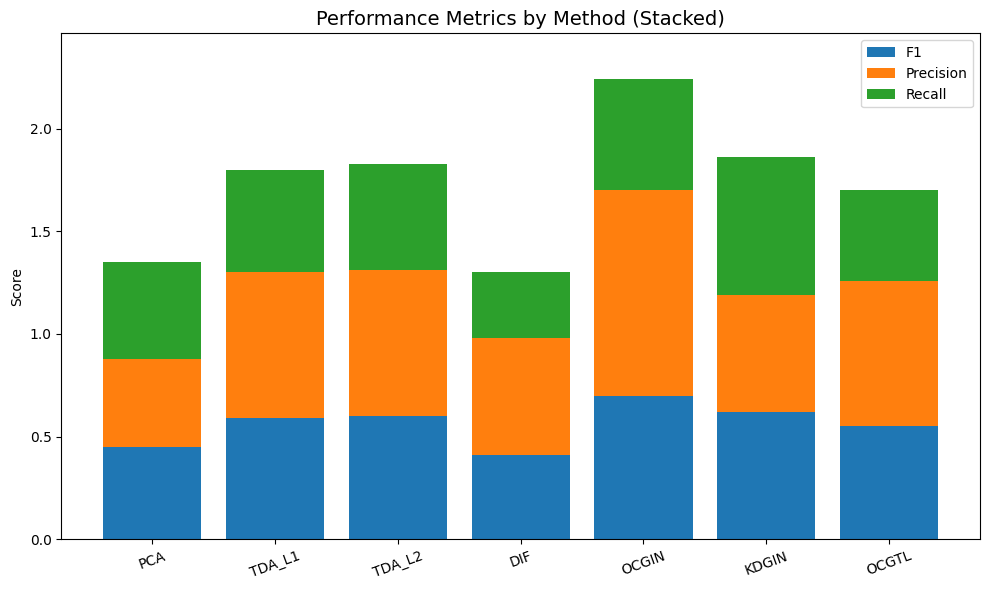

In [74]:
F1 = np.array(results["F1 Score"])
Precision = np.array(results["Precision"])
Recall = np.array(results["Recall"])
methods = np.array(results["Method"])
# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Bottom layers
ax.bar(methods, F1, label="F1", color="#1f77b4")

# Middle layers
ax.bar(methods, Precision, bottom=F1, label="Precision", color="#ff7f0e")

# Top layers
ax.bar(methods, Recall, bottom=F1 + Precision, label="Recall", color="#2ca02c")

# Labels and styling
ax.set_title("Performance Metrics by Method (Stacked)", fontsize=14)
ax.set_ylabel("Score")
ax.set_ylim(0, max(F1 + Precision + Recall) * 1.1)
plt.xticks(rotation=20)
ax.legend()

plt.tight_layout()
plt.show()

## Conclusion

As illustrated in the anomaly plots, all methods were successful in detecting the three main crises (2008-2009, Greek Debt, COVID19). However, the TDA and PCA-based methods had better performance; they significantly better at detecting smaller crises, as illustrated by their higher precision. PCA was able to detect the three major crises because they all involve global changes to the correlation structure where all stocks become highly correlated. However, the smaller stress events involve subtler changes in the structure of the correlation graphs, which was picked up on by the neural network methods and TDA.  

## Resources

For more in-depth details about the GNN/TDA methods and comprehensive experimental results, please refer to the original paper: https://arxiv.org/abs/2604.02549. This paper is intended for readers with an expert-level understanding of the underlying methodologies.